# Analyze gene program analysis result from the spectra model 
- related to Fig S4ABE
- see ./ALTRA-manuscript/Analysis/scRNA/Spectra_analysis for analysis notebook
- Spectra analysis was performed based on instruction https://www.nature.com/articles/s41587-023-01940-3
- compare the gene program activity among CON1, ARI, and ERA

In [1]:
quiet_library <- function(...) {
  suppressPackageStartupMessages(library(...))
}
quiet_library("Seurat")
quiet_library("tidyverse")
quiet_library("ggplot2")
quiet_library("dplyr")
quiet_library("viridis")
quiet_library("lmerTest")
quiet_library("broom.mixed")
quiet_library("data.table")
quiet_library("ggpubr")
quiet_library("rstatix")

Warning message:
“package ‘dplyr’ was built under R version 4.3.3”


In [2]:
# define the color palette to be used
npg_color <- c(
  "#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF",
  "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF"
)
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c(
  "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A",
  "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
  "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00"
)
ari_colors <- c("#4C8CBD", "#F59F00", "#840032")
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
options(repr.plot.width = 20, repr.plot.height = 15)

In [3]:
# define working path
data_path <- "/home/jupyter/data/ra_longitudinal/output_results/Spectra"
fig_path <- "/home/jupyter/data/ra_longitudinal/figures/Spectra"
meta_path <- "/home/jupyter/github/ra-longitudinal/metadata"
output_path <- "/home/jupyter/data/ra_longitudinal/output_results/Spectra"

# define a project name
proj_name <- "ALTRA_Crox_scRNA_Spectra"

In [4]:
source("/home/workspace/github/ALTRA-manuscript/Analysis/scRNA/ALTRA_scRNA_py_helper_functions.py")

## analyze average scores per sample from the single cell analysis

In [5]:
# load the scores
spec_scores <- read_tsv(file.path(data_path, "RA_Cross_sectional_scRNA_Spectra_sample_average_positive_scores.tsv"),
  show_col_types = FALSE
)

New names:
• `` -> `...1`


In [9]:
samples_numbers <- spec_scores %>%
  distinct(sample.sampleKitGuid, .keep_all = TRUE) %>%
  group_by(Status_Xsec) %>%
  tally()
samples_numbers
# remove factor that more than half of the samples are 0
factor_keep <- spec_scores %>%
  filter(nonzero_percentage > 0) %>%
  group_by(Spectra_factor, AIFI_L1_5) %>%
  tally() %>%
  filter(n >= sum(samples_numbers$n) / 2) %>%
  pull(Spectra_factor) %>%
  unique()

Status_Xsec,n
<chr>,<int>
ALTRA_healthy,31
at_risk,45
early_RA,12


In [10]:
# filter the score dataframe
spec_scores_fl <- spec_scores %>%
  filter(AIFI_L1_5 != "ILC" & Spectra_factor %in% factor_keep) %>%
  mutate(
    Status_Xsec = factor(Status_Xsec, levels = c("ALTRA_healthy", "at_risk", "early_RA")),
    status = factor(recode(Status_Xsec, "ALTRA_healthy" = "CON1", "at_risk" = "ARI", "early_RA" = "ERA"),
      levels = c("CON1", "ARI", "ERA")
    )
  ) %>%
  mutate(batch_corr = if_else(file.batchID == "B182", "B182", "Other")) %>%
  filter(!str_detect(Spectra_factor, "-X-ILC-X-"))

### output score table

In [18]:
# save an excel file for sup table
spec_scores_excel <- spec_scores_fl %>%
  select(-c(
    `...1`, Status_Xsec, Status_Long, CMV_Status_Subj, anti_ccp3_finalCombined,
    batch_corr
  )) %>%
  rename("Sex" = "subject.biologicalSex", "AIFI level 1 Cell type" = "AIFI_L1_5")
spec_scores_excel %>% writexl::write_xlsx(file.path(data_path, "Table_S13_Spectra_average_scores.xlsx"),
  col_names = TRUE
)

In [28]:
spec_scores_output <- spec_scores_fl %>%
  rename(
    "cell_type" = "AIFI_L1_5", "batch_correction" = "batch_corr", "CCP3" = "anti_ccp3_finalCombined",
    "Sex" = "subject.biologicalSex", "CMV" = "CMV_Status_Subj"
  ) %>%
  select(c(
    sample.sampleKitGuid, cell_type, Spectra_factor, mean_score, nonzero_percentage,
    BMI, Sex, CMV, age, status, CCP3, batch_correction
  ))
spec_scores_output %>% head()

sample.sampleKitGuid,cell_type,Spectra_factor,mean_score,nonzero_percentage,BMI,Sex,CMV,age,status,CCP3,batch_correction
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<fct>,<dbl>,<chr>
KT00052,CD4_T,0-X-global-X-all_chondroitine-and-heparan-sulfate_synthesis,0.0001827638,44.53024,24.65716,Female,Negative,56,ARI,88,Other
KT00052,CD8_T,0-X-global-X-all_chondroitine-and-heparan-sulfate_synthesis,0.0001856450,47.79614,24.65716,Female,Negative,56,ARI,88,Other
KT00052,DC,0-X-global-X-all_chondroitine-and-heparan-sulfate_synthesis,0.0001803807,46.66667,24.65716,Female,Negative,56,ARI,88,Other
KT00052,Memory B cell,0-X-global-X-all_chondroitine-and-heparan-sulfate_synthesis,0.0001782096,40.39735,24.65716,Female,Negative,56,ARI,88,Other
KT00052,NK,0-X-global-X-all_chondroitine-and-heparan-sulfate_synthesis,0.0002093238,55.80808,24.65716,Female,Negative,56,ARI,88,Other
KT00052,Naive B cell,0-X-global-X-all_chondroitine-and-heparan-sulfate_synthesis,0.0001905790,42.30769,24.65716,Female,Negative,56,ARI,88,Other


In [29]:
# save the scores
spec_scores_output %>%
  write_csv(file.path(output_path, "ALTRA_scRNA_Spectra_average_positive_scores.csv"))

## get top10 genes for each factor

In [13]:
# load the gene weight for factor
gene_weight <- fread(file.path(output_path, "RA_Cross_sectional_scRNA_Spectra_gene_weight.csv")) %>% rename("gene" = "V1")
gene_weight %>% head()

gene,0-X-global-X-all_chondroitine-and-heparan-sulfate_synthesis,1-X-global-X-all_retinol_metabolism,2-X-global-X-all_RIG-I-like-receptor_signaling,3-X-global-X-all_propanoate_metabolism,4-X-global-X-all_p53-signaling,5-X-global-X-all_macroautophagy,6-X-global-X-all_circadian-rhythm,7-X-global-X-all_VAL-LEU-ILE_metabolism,8-X-global-X-all_taurine-hypotaurine_metabolism,⋯,213-X-Treg-X-TNK_IL2-STAT5-signaling,214-X-Treg-X-Treg_FoxP3-stabilization,215-X-Treg-X-CD4-T_TH22_UP,216-X-Treg-X-216,217-X-Treg-X-217,218-X-gdT-X-TNK_cytotoxicity-effectors,219-X-mono-X-all_TNF-via-NFkB_signaling,220-X-mono-X-220,221-X-mono-X-221,222-X-mono-X-all_DNA-demethylation
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
FAM41C,8.375776e-16,3.779302e-15,9.932433e-16,1.178150e-15,9.086410e-16,5.330064e-16,1.004214e-15,8.322381e-16,2.970326e-15,⋯,1.212272e-03,1.917657e-11,1.151275e-08,1.057835e-03,3.764165e-02,0.012487325,1.569990e-10,8.267860e-04,2.759593e-03,0.0032036398
ISG15,3.046103e-14,8.249192e-14,4.493381e-03,9.817519e-14,2.005391e-14,2.463410e-14,5.960023e-14,6.037471e-14,1.157622e-15,⋯,2.066785e-09,3.615304e-12,1.527407e-02,1.339112e-02,5.614168e-05,0.037229232,1.439293e-13,1.502581e-13,8.126815e-12,0.0021422175
TNFRSF18,3.366851e-16,4.110050e-16,4.023495e-16,6.936347e-16,4.552718e-16,2.465864e-16,5.659576e-16,3.870110e-16,3.859068e-16,⋯,1.050831e-02,7.897715e-09,3.012729e-02,6.896984e-03,9.769645e-05,0.008664161,1.077570e-14,1.344668e-15,2.927952e-15,0.0003979452
TNFRSF4,8.473794e-14,1.388141e-13,6.277845e-14,1.056513e-13,4.186695e-14,1.687665e-14,1.642458e-13,1.133664e-13,2.064433e-14,⋯,1.785871e-02,5.211456e-04,2.152280e-05,1.273061e-02,5.520095e-03,0.004205376,6.710162e-15,2.933707e-15,2.839771e-15,0.0003334873
B3GALT6,4.182406e-02,1.694247e-13,4.791173e-14,1.044946e-11,9.508932e-12,3.650819e-14,1.367095e-13,1.084235e-10,5.307352e-14,⋯,4.750036e-14,3.360701e-14,5.484951e-14,1.437800e-14,1.270712e-03,0.007500864,9.721312e-13,1.886484e-03,2.414606e-03,0.0112283004
UBE2J2,1.810953e-10,5.127512e-11,5.740048e-06,4.043606e-07,4.819979e-08,2.100249e-07,1.017559e-07,3.062118e-08,1.214851e-05,⋯,1.026852e-11,5.071106e-04,3.716377e-03,9.134931e-04,4.059168e-02,0.014592452,1.681013e-14,3.167538e-14,9.014730e-12,0.0354026382


In [14]:
# get to 10 gene by weight
top10_gene_weight <- gene_weight %>%
  pivot_longer(cols = -gene, names_to = "Spectra_factor", values_to = "weight") %>%
  group_by(Spectra_factor) %>%
  slice_max(order_by = weight, n = 10) %>%
  ungroup()

In [15]:
top10_genes <- top10_gene_weight %>%
  group_by(Spectra_factor) %>%
  summarise(top10_genes = paste(gene, collapse = ", "))
top10_genes %>% head()

Spectra_factor,top10_genes
<chr>,<chr>
0-X-global-X-all_chondroitine-and-heparan-sulfate_synthesis,"CHST11, CSGALNACT2, B4GALT7, HS2ST1, EXT2, B3GAT2, CHPF2, CHSY1, XYLT2, HS3ST3B1"
1-X-global-X-all_retinol_metabolism,"RDH14, PNPLA4, RDH13, RDH5, RDH10, RDH11, RDH16, MKRN1, LRAT, RDH12"
10-X-global-X-all_transmembrane-transport-ER,"SLC33A1, XIST, SLC35D1, MAN1A2, SLC37A4, ITPR2, BRAF, HEXIM1, MAVS, POLR3A"
100-X-global-X-all_ascorbate-uptake,"MTRNR2L8, SLC23A2, MT-ATP8, HBB, IGHM, XIST, EPG5, IGHA1, RUBCN, NBR1"
101-X-global-X-all_ketone-body_metabolism,"ACAT2, OXCT1, HMGCL, ACSS1, BDH1, SLC16A1, AACS, ACSS2, LDHB, ACAT1"
102-X-global-X-all_keratan-sulfate_degradation,"HEXA, AGA, NEU1, HEXB, FUCA1, GALNS, GLB1, FUCA2, GNS, NAGA"


## run glm model for scores

In [21]:
# Function to run glm analysis on a data frame
# Args:
#   df: The data frame containing the data
#   formula: The formula specifying the model
#   factor: The factor variable to include in the analysis
# Returns:
#   The tidy results of the glm analysis with the factor variable added
RunGlm <- function(df, formula, factor) {
  glm_res <- broom::tidy(stats::glm(as.formula(formula), data = df)) %>%
    mutate("Spectra_factor" = factor)
  return(glm_res)
}

# Function to run glm analysis on multiple factors in parallel
# Args:
#   spec_scores: The data frame containing the data
#   formula: The formula specifying the model
#   mc.cores: The number of cores to use for parallel processing (default is 1)
# Returns:
#   The combined results of the glm analysis for all factors, with adjusted p-values and significance added
RunGlmFactor <- function(spec_scores, formula, mc.cores = 1) {
  glm_results <- parallel::mclapply(unique(spec_scores$Spectra_factor), function(factor) {
    message(factor)
    if (str_detect(factor, "global")) {
      glm_test <- spec_scores %>%
        filter(Spectra_factor == factor) %>%
        group_by(AIFI_L1_5) %>%
        group_modify(~ RunGlm(.x, formula = formula, factor = factor))
    } else {
      cell_type <- str_split(factor, "-X-")[[1]][2]
      glm_test <- spec_scores %>%
        filter(Spectra_factor == factor & AIFI_L1_5 == cell_type) %>%
        group_by(AIFI_L1_5) %>%
        group_modify(~ RunGlm(.x, formula = formula, factor = factor))
    }
    glm_test <- glm_test %>% mutate("Spectra_factor" = factor)
    return(glm_test)
  }, mc.cores = mc.cores) %>%
    rbindlist()
  return(glm_results)
}

In [23]:
glm_results <- RunGlmFactor(
  spec_scores = spec_scores_fl,
  formula = "mean_score ~ status + subject.biologicalSex + age + BMI + batch_corr",
  mc.cores = 15
)

In [24]:
glm_results %>% head()

AIFI_L1_5,term,estimate,std.error,statistic,p.value,Spectra_factor
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
CD4_T,(Intercept),2.053893e-04,6.212791e-06,33.0591006,2.075344e-48,0-X-global-X-all_chondroitine-and-heparan-sulfate_synthesis
CD4_T,statusARI,6.281000e-07,2.281762e-06,0.2752698,7.838187e-01,0-X-global-X-all_chondroitine-and-heparan-sulfate_synthesis
CD4_T,statusERA,2.688511e-06,3.227019e-06,0.8331253,4.072545e-01,0-X-global-X-all_chondroitine-and-heparan-sulfate_synthesis
CD4_T,subject.biologicalSexMale,-3.216163e-06,2.537753e-06,-1.2673274,2.087149e-01,0-X-global-X-all_chondroitine-and-heparan-sulfate_synthesis
CD4_T,age,9.045180e-09,6.142359e-08,0.1472591,8.832980e-01,0-X-global-X-all_chondroitine-and-heparan-sulfate_synthesis
CD4_T,BMI,-7.939985e-08,1.721647e-07,-0.4611855,6.459169e-01,0-X-global-X-all_chondroitine-and-heparan-sulfate_synthesis


In [25]:
glm_results_status <- glm_results %>%
  filter(term %in% c("statusARI", "statusERA")) %>%
  group_by(term, AIFI_L1_5) %>%
  group_modify(~ calQvalue(.x, p_col = "p.value")) %>%
  rename("p.adj" = "q_values") %>%
  rstatix::add_significance("p.adj") %>%
  arrange(p.adj) %>%
  ungroup()

Loading required package: qvalue



In [35]:
# add top10 gene into the results table
glm_results_status <- glm_results_status %>% left_join(top10_genes, by = "Spectra_factor")

In [37]:
glm_results_status %>% write_csv(file.path(output_path, paste0(proj_name, "factor_glm_test_result.csv")))

In [24]:
glm_results_status <- read_csv(file.path(output_path, paste0(proj_name, "factor_glm_test_result.csv")))

Rows: 3756 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (5): term, AIFI_L1_5, Spectra_factor, p.adj.signif, top10_genes
dbl (5): estimate, std.error, statistic, p.value, p.adj

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [33]:
# save result for sup table
glm_sig <- glm_results_status %>%
  filter(p.adj < 0.05) %>%
  mutate(group = str_remove(term, "status")) %>%
  select(c(AIFI_L1_5, Spectra_factor, group, estimate, p.value, p.adj, top10_genes)) %>%
  rename(
    "AIFI L1 cell type" = "AIFI_L1_5", "Spectra Factor" = "Spectra_factor", "Effect Size" = "estimate",
    "Adjusted p values (q values)" = "p.adj"
  )
glm_sig %>% writexl::write_xlsx(file.path(data_path, "Table_S14_Spectra_scores_glm_results.xlsx"),
  col_names = TRUE
)

## plot Fig S4A

`summarise()` has grouped output by 'status'. You can override using the
`.groups` argument.


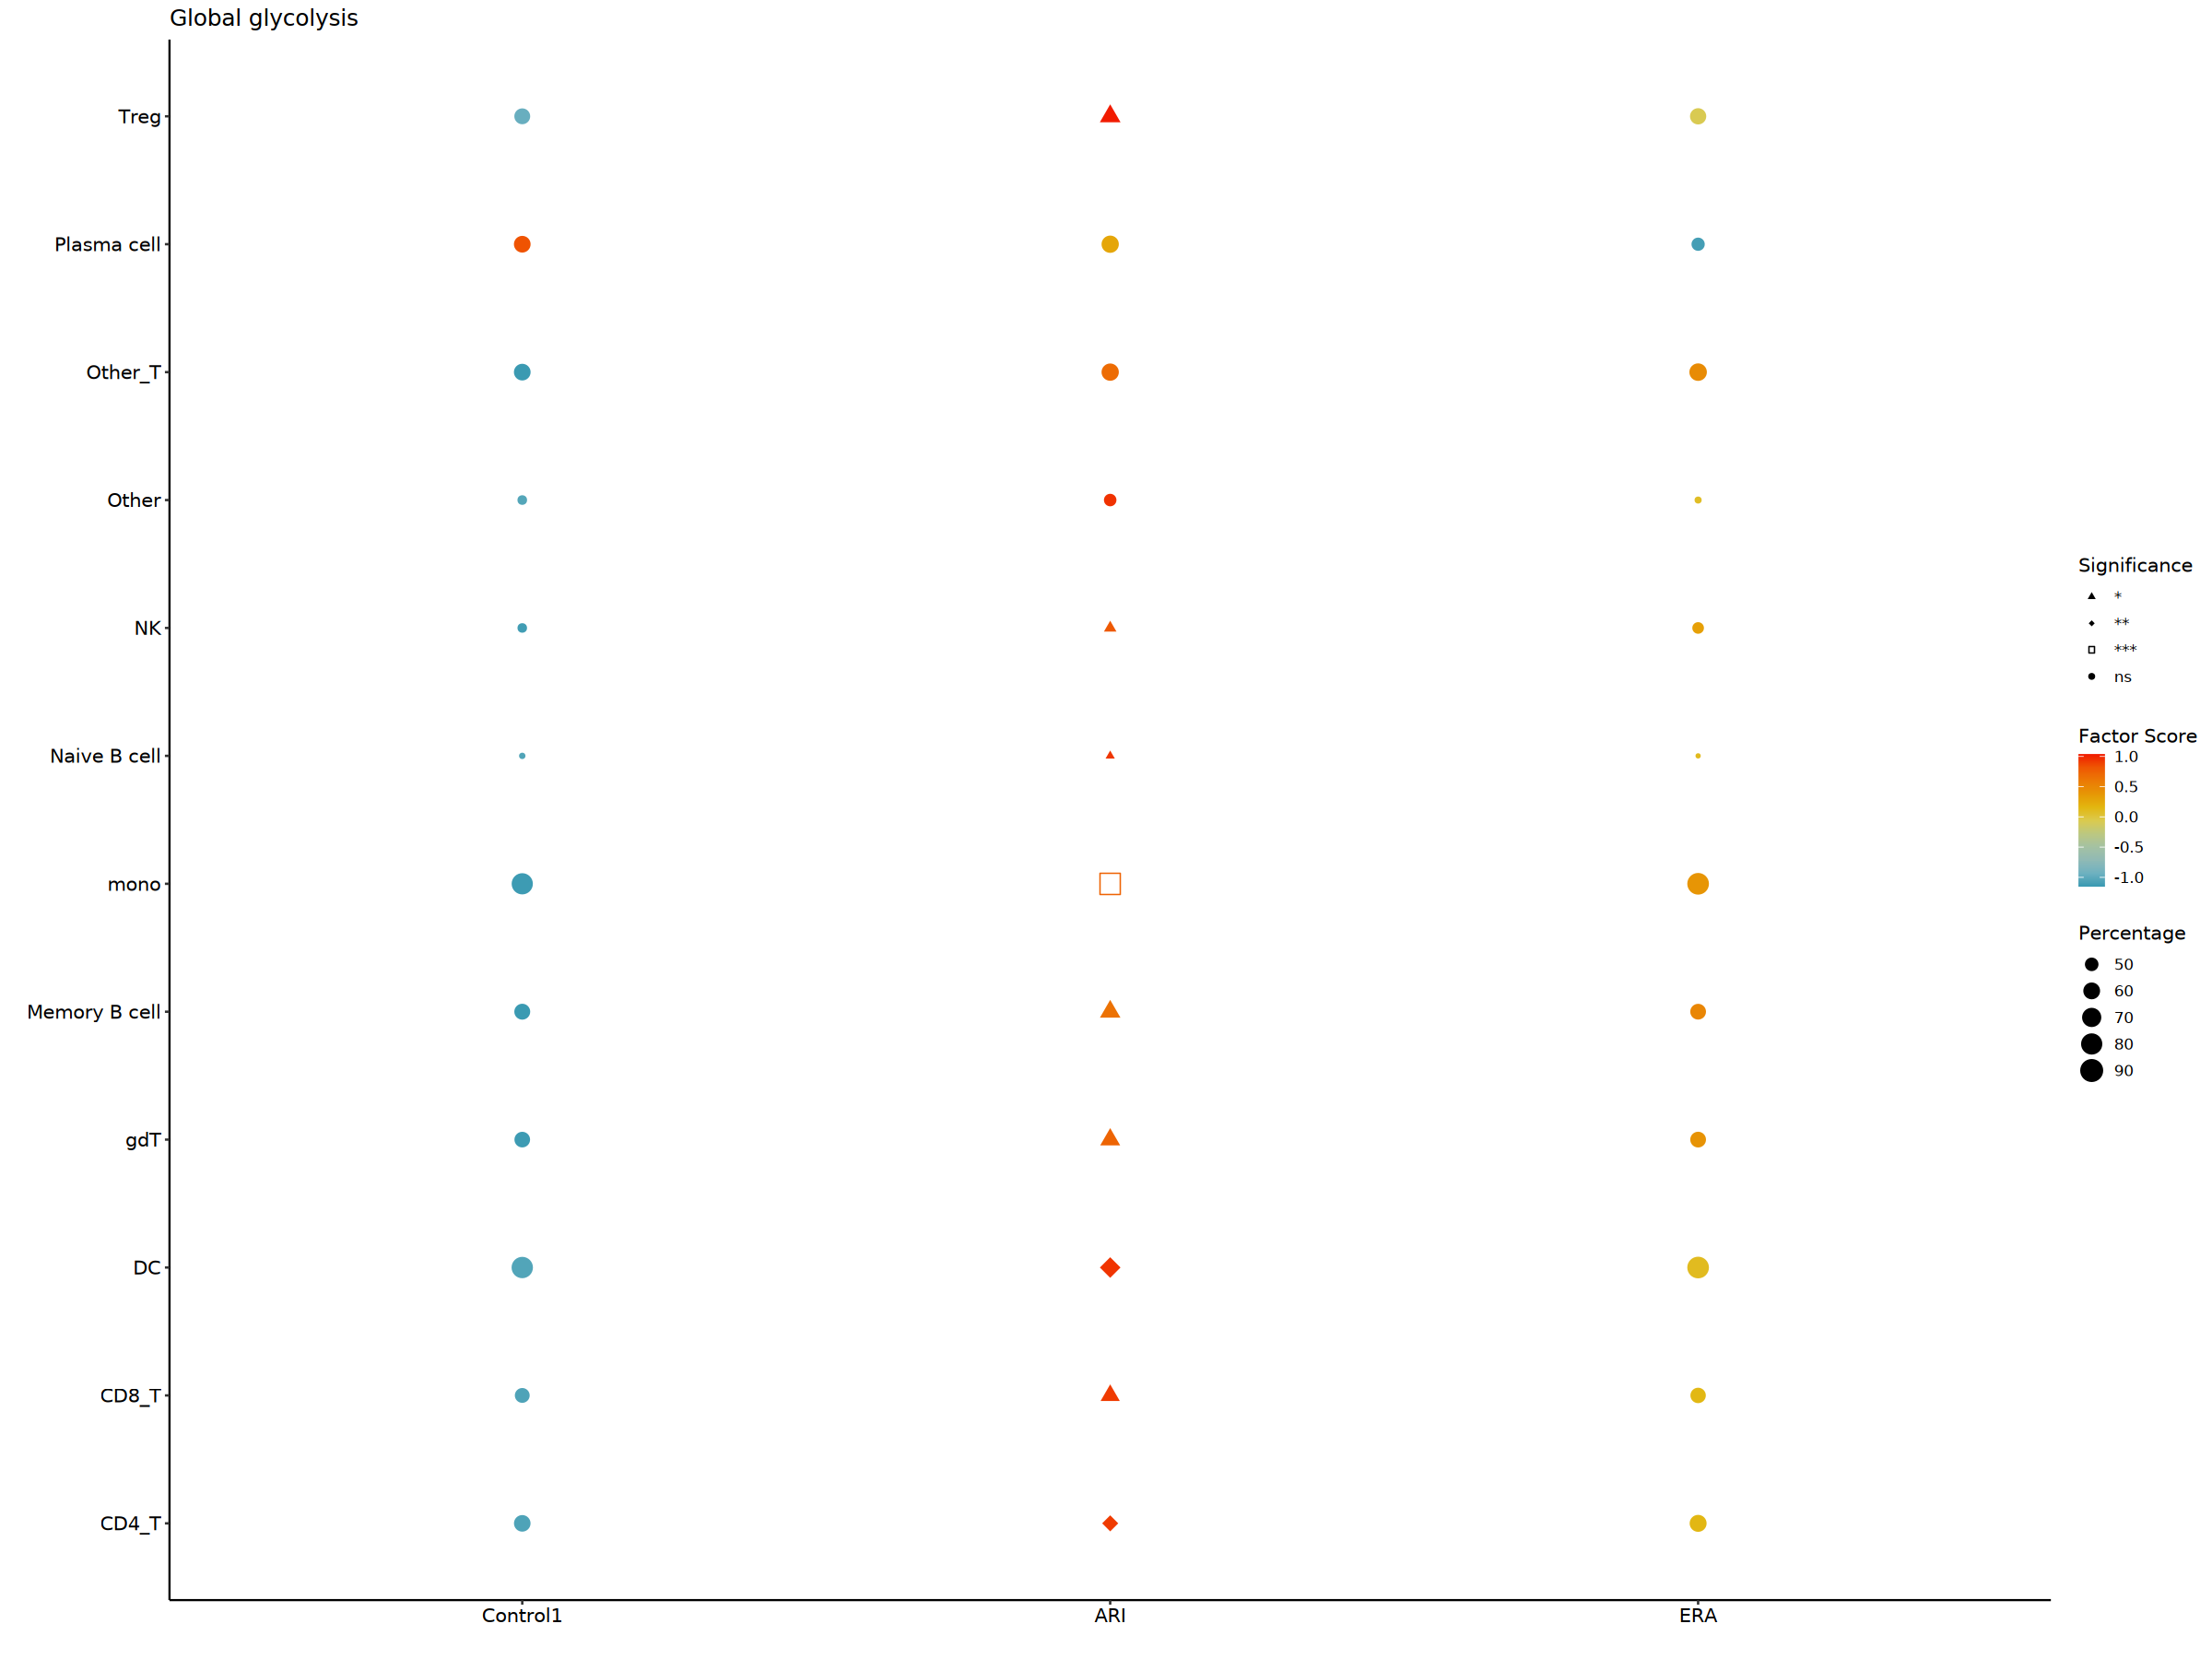

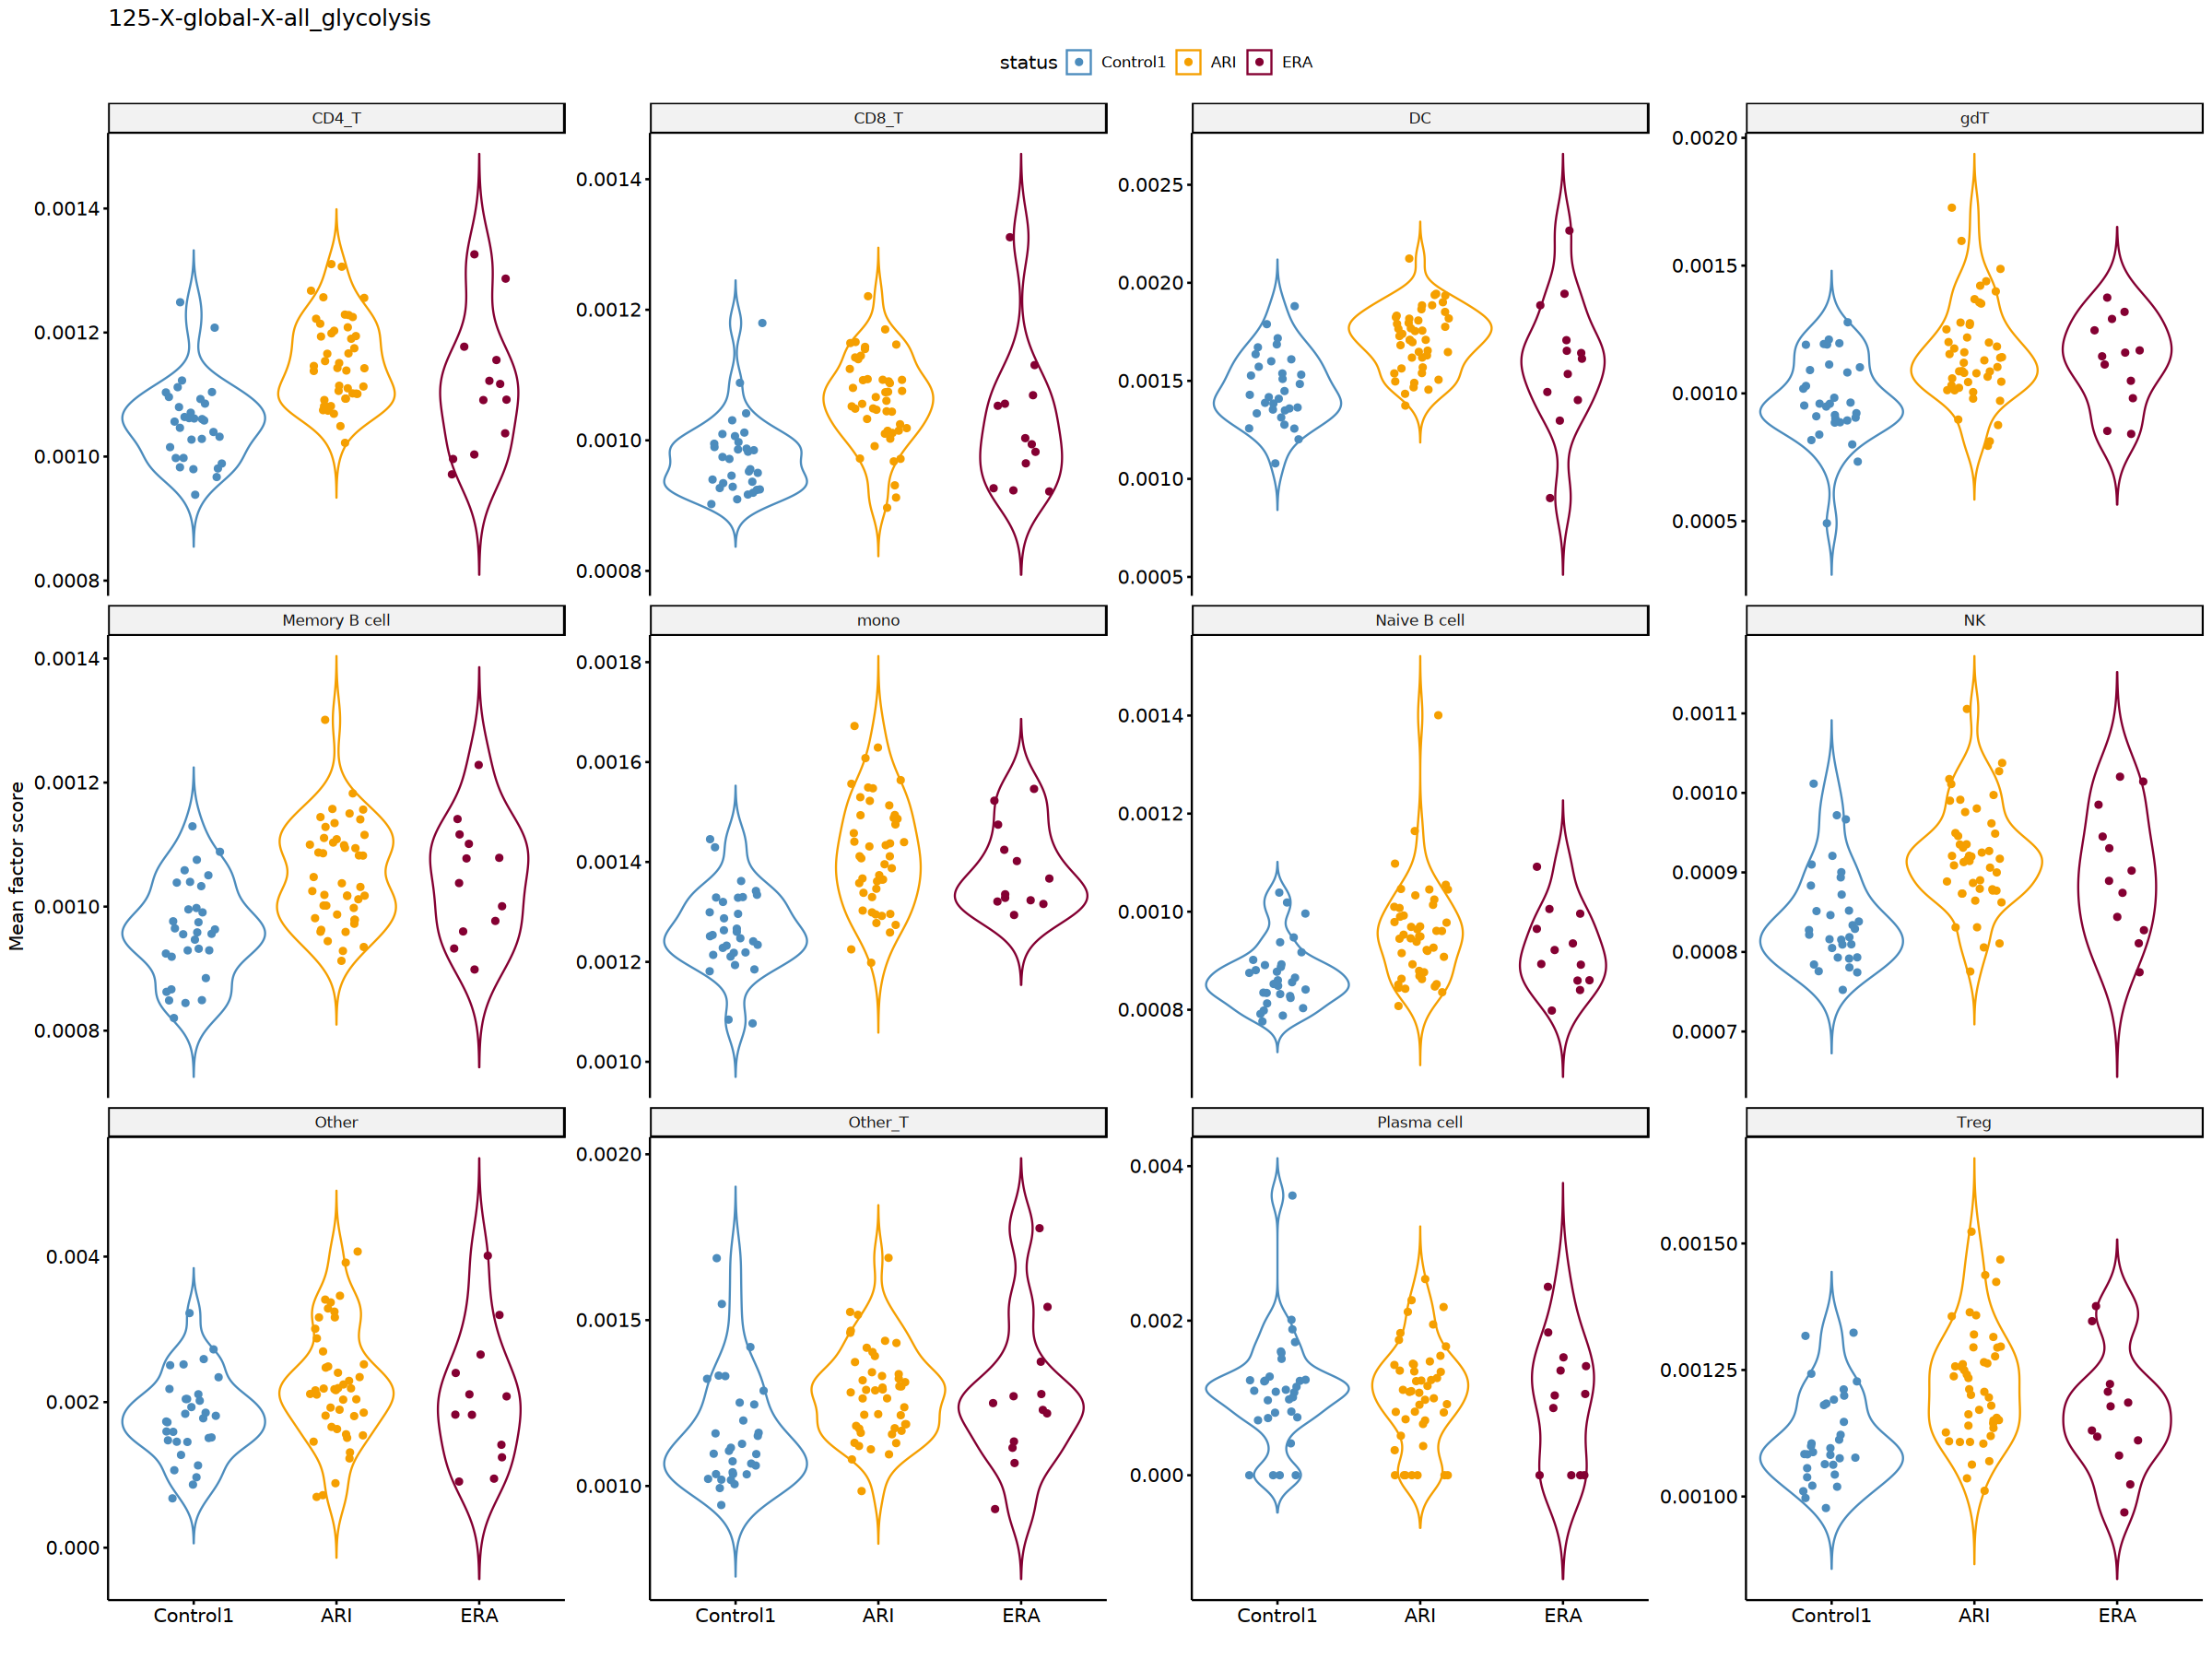

In [212]:
factor_name <- "125-X-global-X-all_glycolysis"
p1 <- PlotFactorDot(spec_scores_fl,
  stats_table = glm_results_status,
  factor_name = factor_name
) + ggtitle("Global glycolysis")
p1
ggsave(file.path(fig_path, paste0(proj_name, factor_name, "_pathway_enrichment_dotplot.pdf")),
  plot = p1, width = 5, height = 5
)
# Save the plot
p2 <- PlotFactor(spec_scores_fl,
  factor_name = factor_name, fig_path, proj_name
)
p2

## plot Fig S4B

`summarise()` has grouped output by 'status'. You can override using the
`.groups` argument.


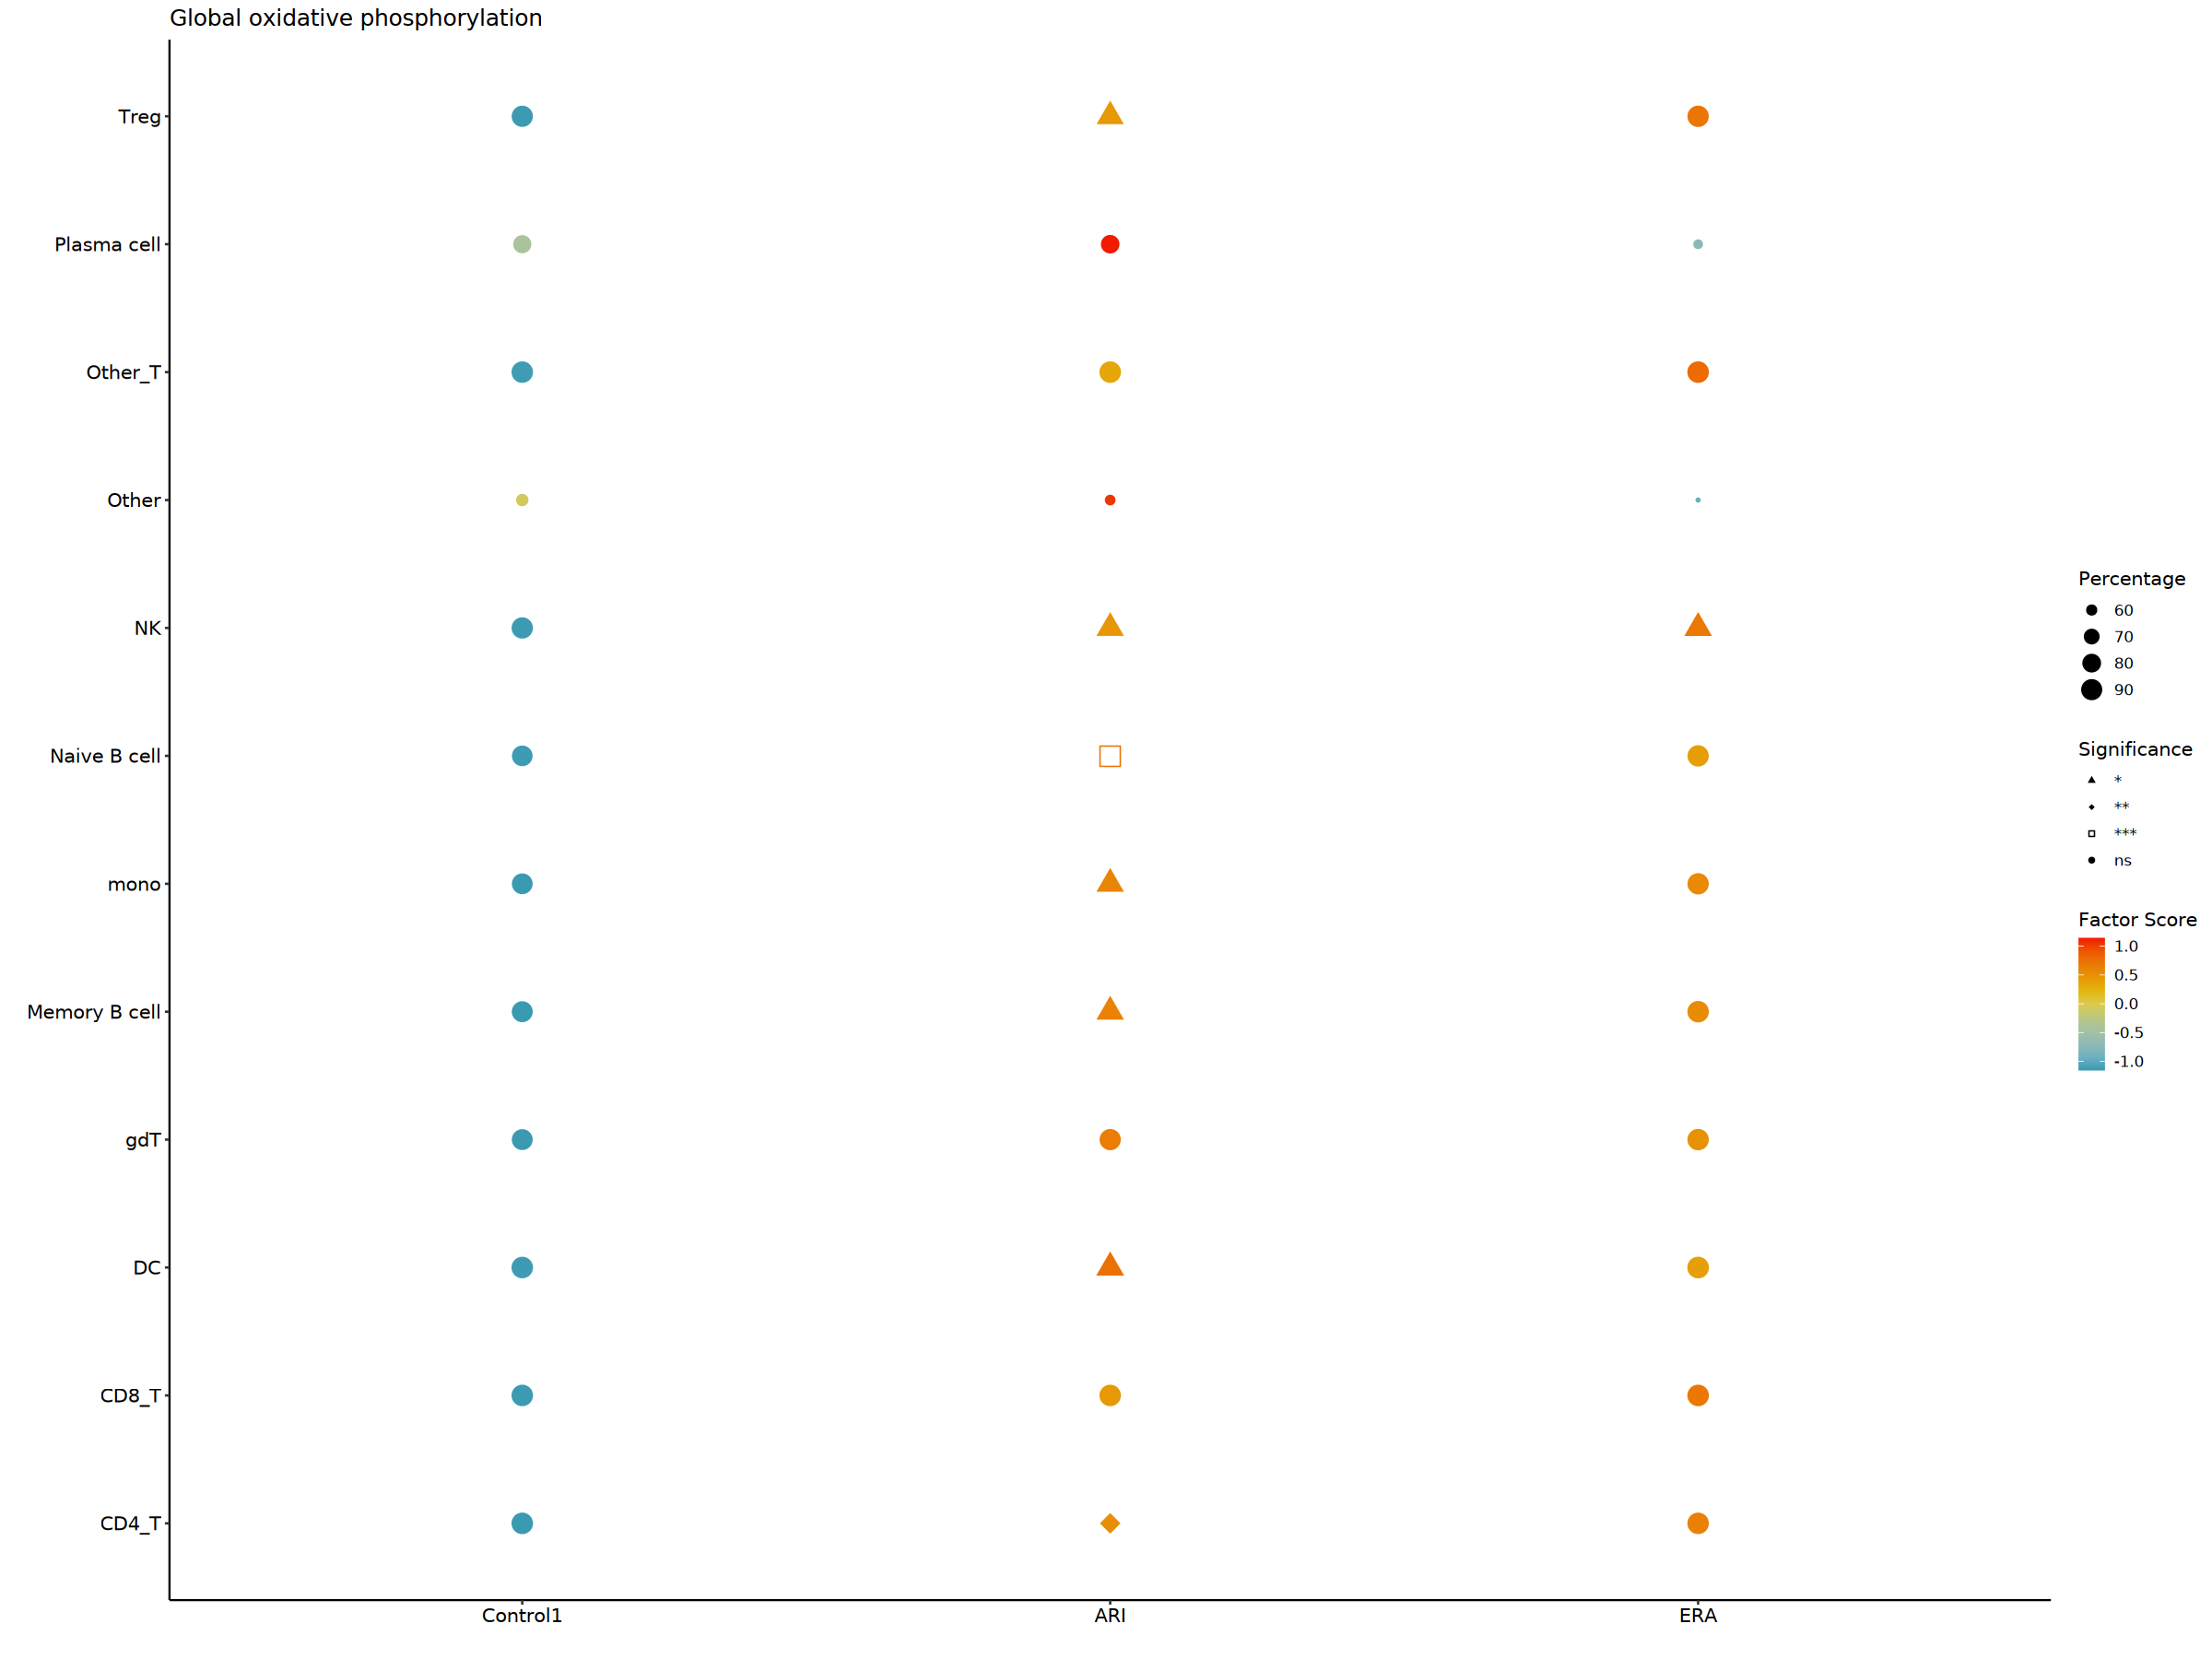

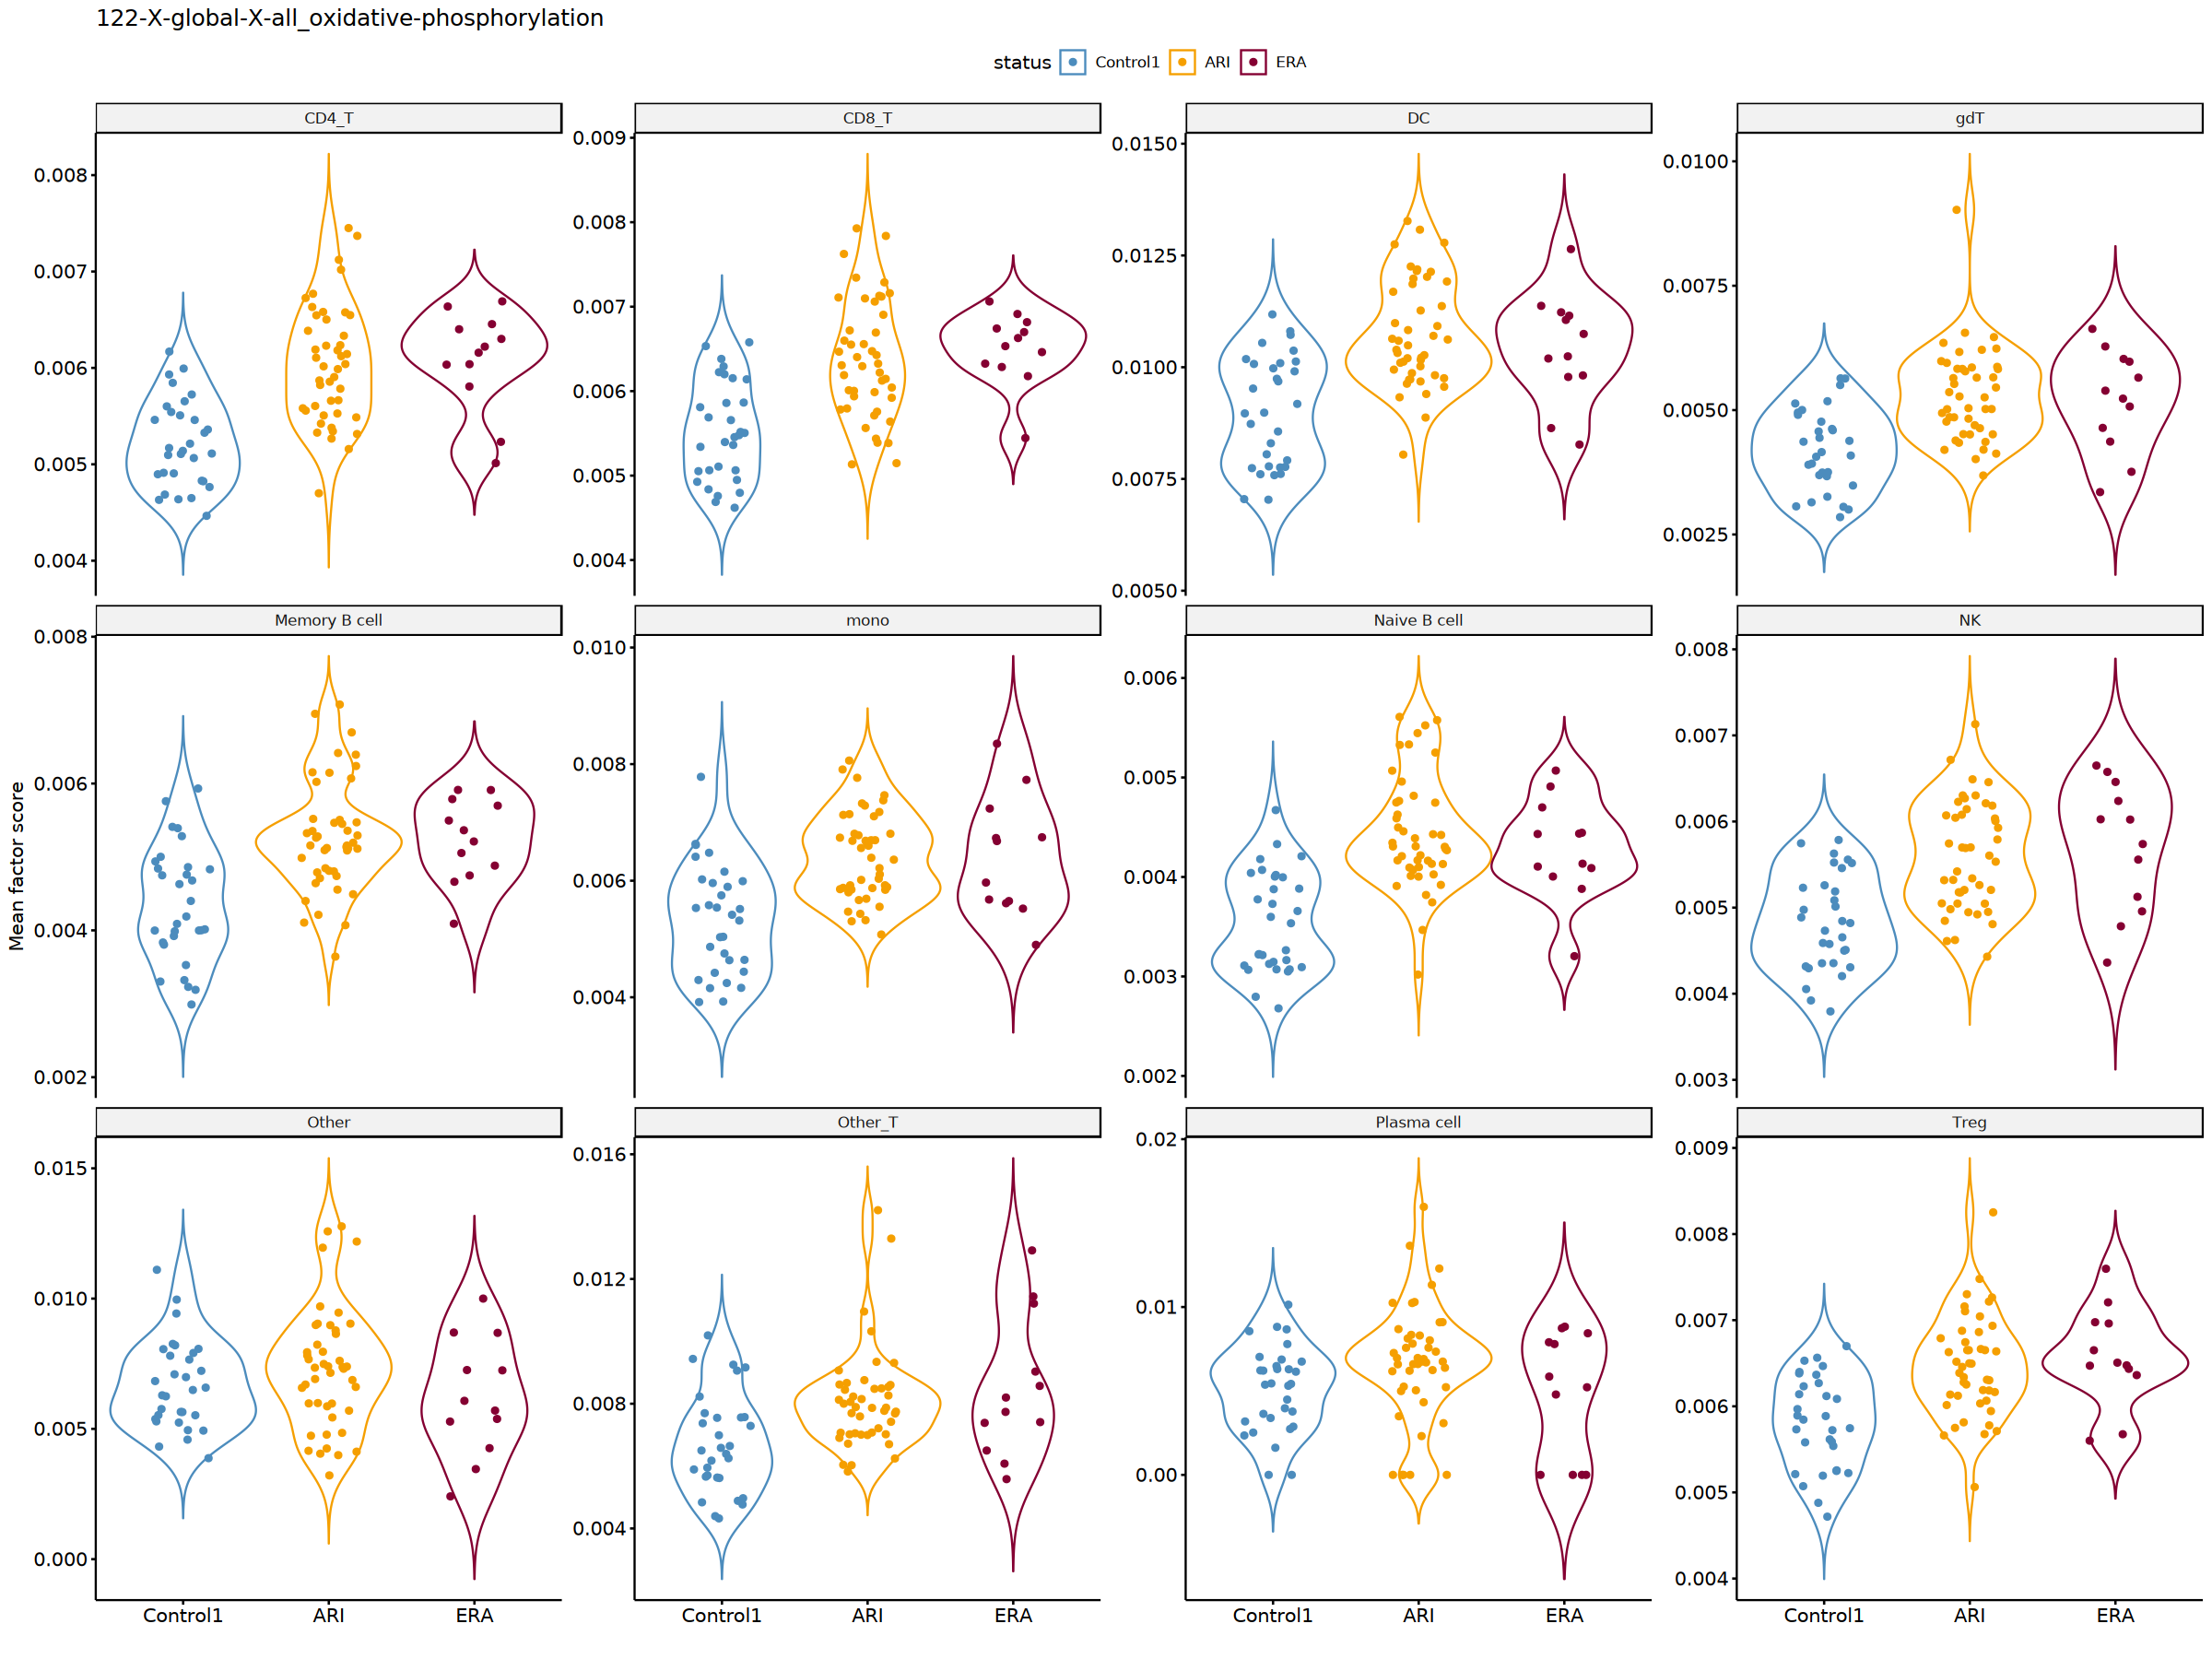

In [213]:
factor_name <- "122-X-global-X-all_oxidative-phosphorylation"
p1 <- PlotFactorDot(spec_scores_fl,
  stats_table = glm_results_status,
  factor_name = factor_name
) + ggtitle("Global oxidative phosphorylation")
p1
ggsave(file.path(fig_path, paste0(proj_name, factor_name, "_pathway_enrichment_dotplot.pdf")),
  plot = p1, width = 5, height = 5
)
# Save the plot
p2 <- PlotFactor(spec_scores_fl,
  factor_name = factor_name, fig_path, proj_name
)
p2

## plot Fig S4B

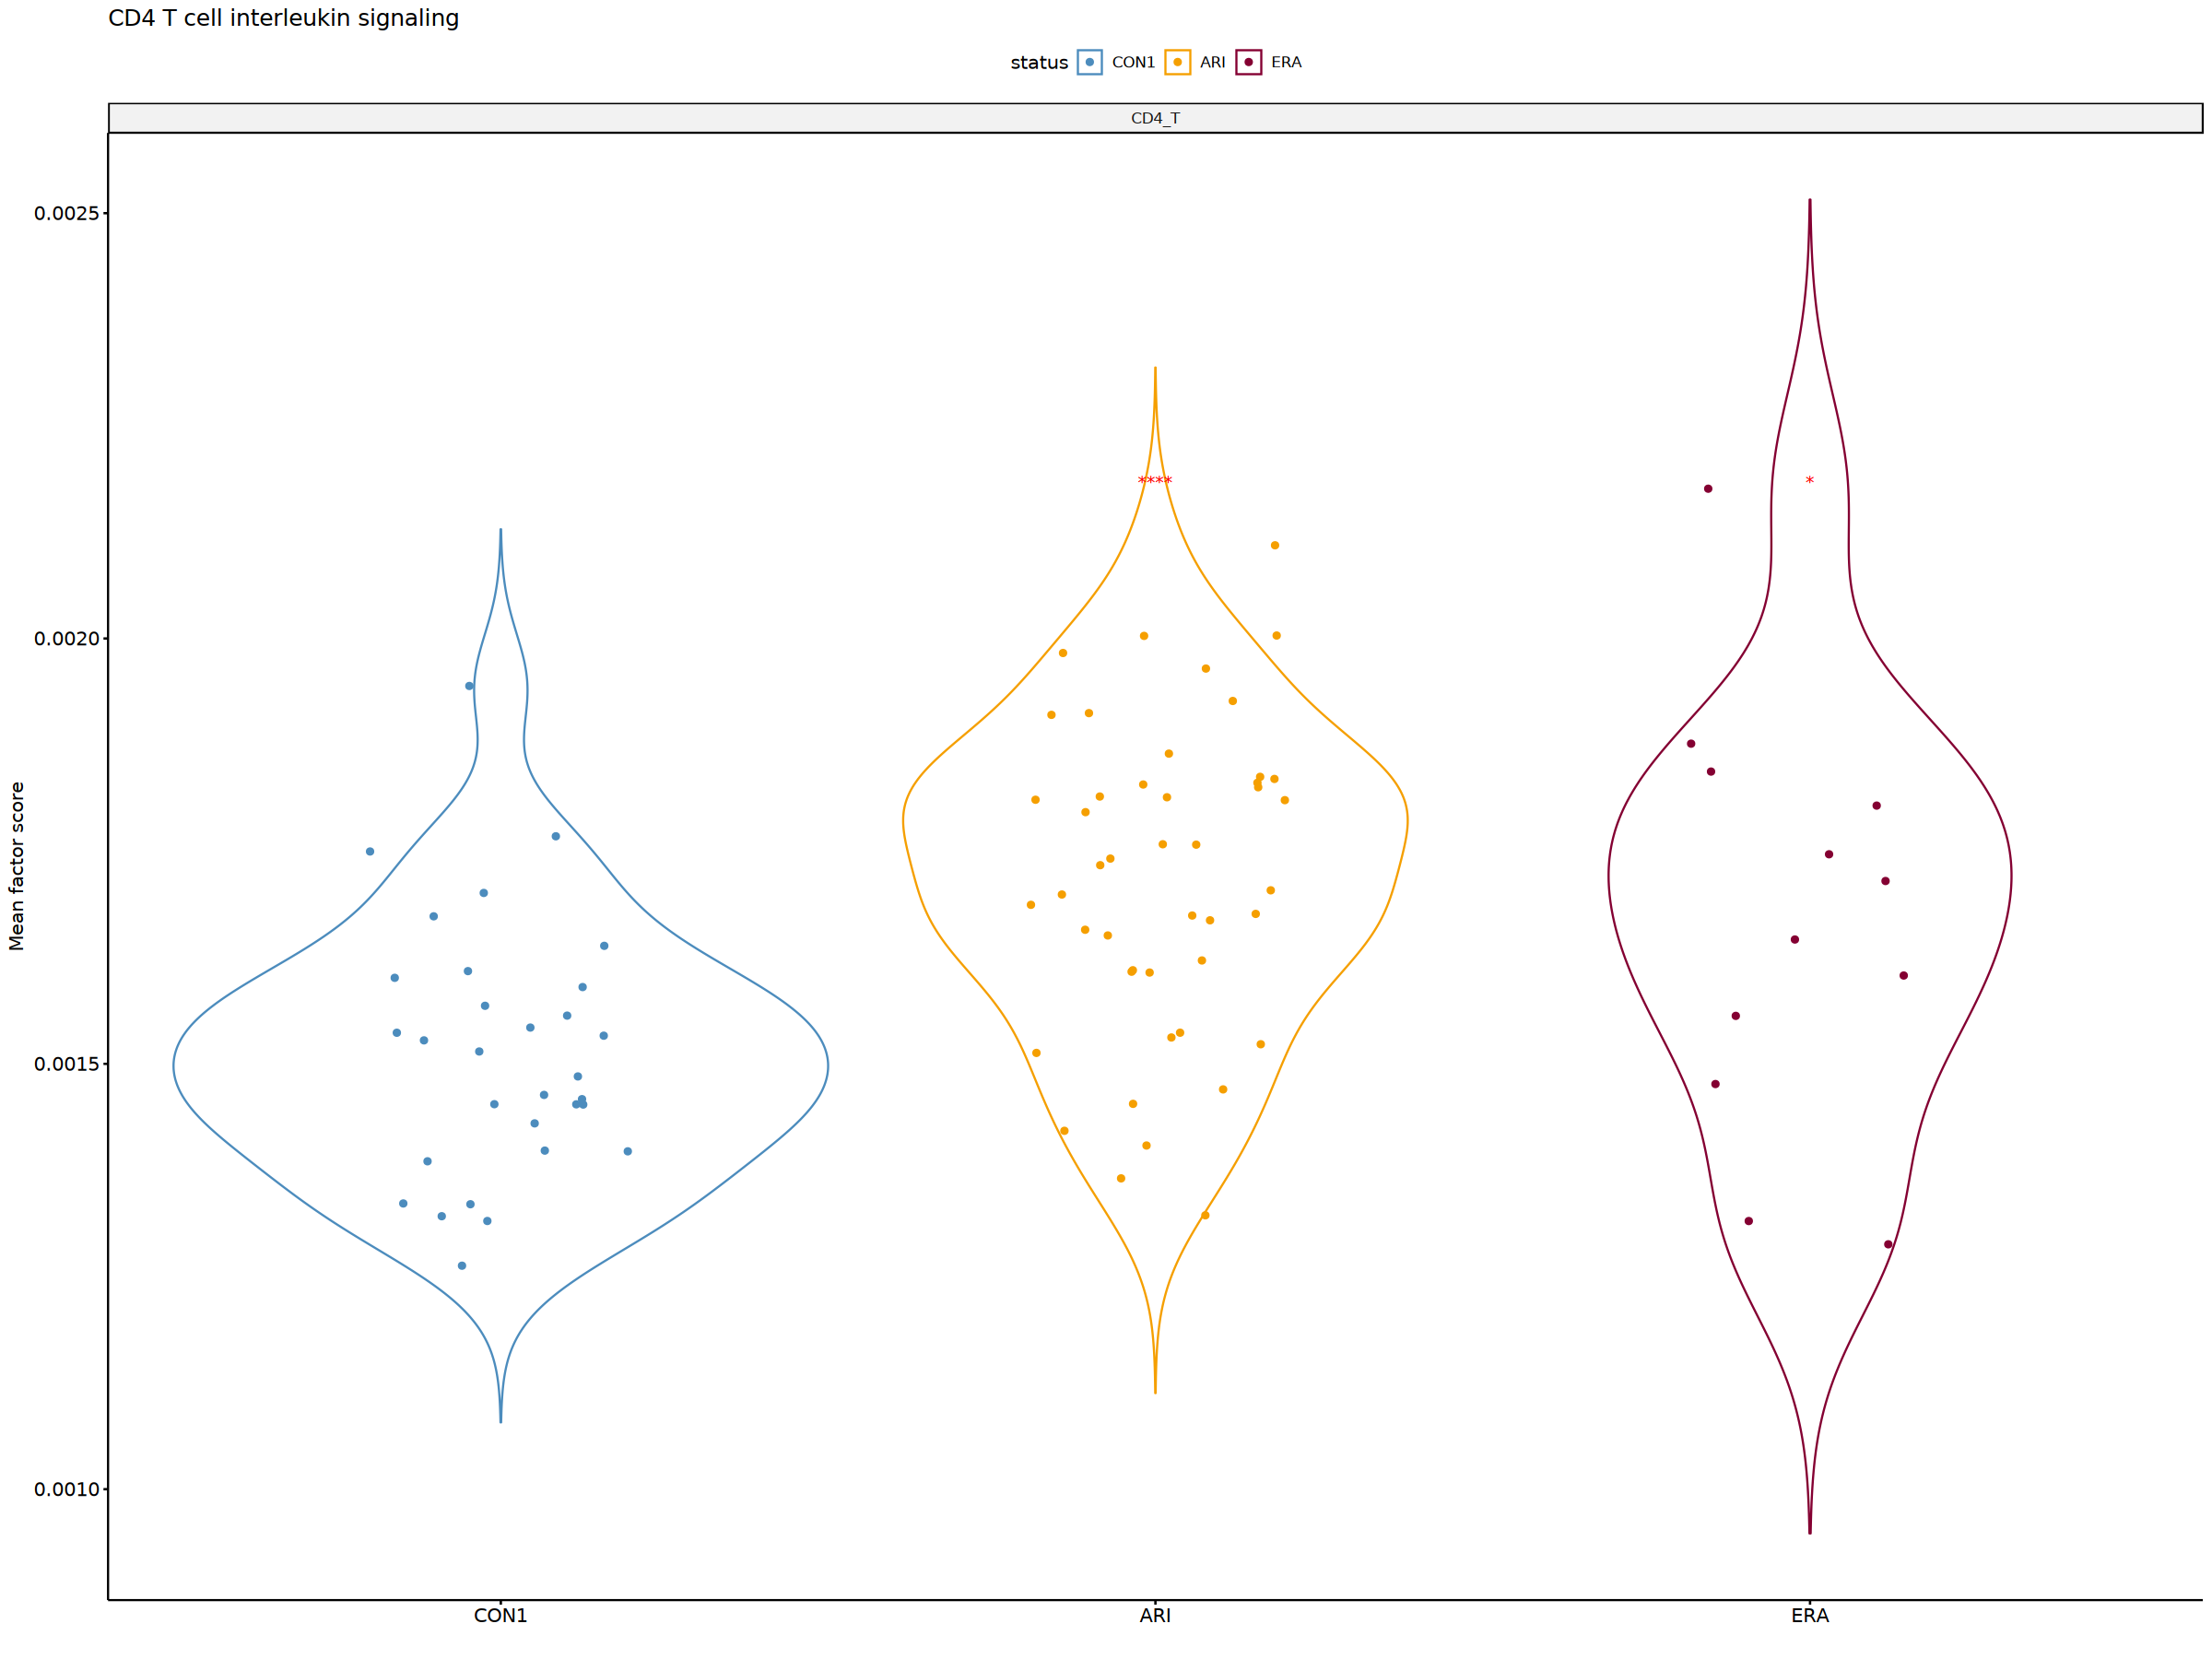

In [68]:
# plot the specific factor
# based on the edge genes in the graph; it is not clear that this pathway related to IL4 signaling specifically
# more likely general interleukin signaling
factor_name <- "152-X-CD4_T-X-CD4-T_IL4_response"
p1 <- PlotFactor(spec_scores_fl %>% filter(AIFI_L1_5 == "CD4_T"), factor_name,
  my_comparisons = my_comparisons,
  title = "CD4 T cell interleukin signaling",
  width = 4, height = 4, fig_path = fig_path, proj_name = proj_name
)
p1